In [3]:
print(4+9)

13


Movies Dataset:
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [

C:\Users\khali\AppData\Local\Temp\ipykernel_19212\425549780.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['tags'] = new_data['tags'].apply(lambda x: x.lower())



Vector Shape:
(4806, 5000)

Similarity Matrix Created!

Recommended Movies:

Jupiter Ascending
The Martian
The Amazing Spider-Man
Spectre
2012


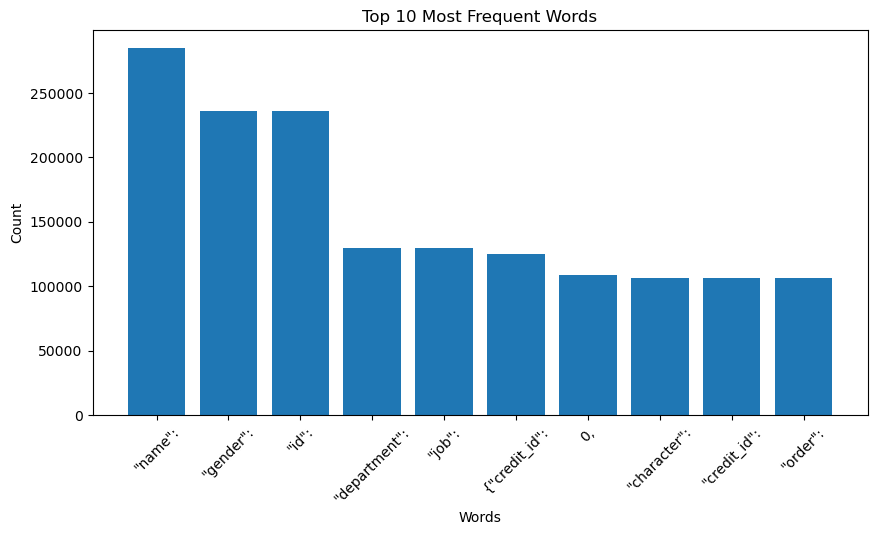

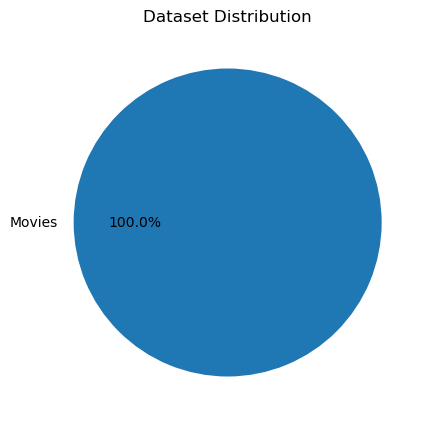

In [4]:
# ====================================================
# MOVIE RECOMMENDATION SYSTEM USING MACHINE LEARNING
# ====================================================

# -------------------------------
# STEP 1 : Import Libraries
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Text vectorization
from sklearn.feature_extraction.text import CountVectorizer

# Similarity calculation
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# STEP 2 : Load Dataset
# -------------------------------

movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

print("Movies Dataset:")
print(movies.head())

# -------------------------------
# STEP 3 : Merge Datasets
# -------------------------------

# Common column 'title' par merge karenge

movies = movies.merge(credits, on='title')

print("\nMerged Dataset Shape:")
print(movies.shape)

# -------------------------------
# STEP 4 : Select Important Columns
# -------------------------------

movies = movies[[
    'movie_id',
    'title',
    'overview',
    'genres',
    'keywords',
    'cast',
    'crew'
]]

print("\nSelected Columns:")
print(movies.head())

# -------------------------------
# STEP 5 : Handle Missing Values
# -------------------------------

movies.dropna(inplace=True)

print("\nDataset After Removing Missing Values:")
print(movies.shape)

# -------------------------------
# STEP 6 : Combine Features
# -------------------------------

# Hum important text columns combine karenge

movies['tags'] = (
    movies['overview'] +
    movies['genres'] +
    movies['keywords'] +
    movies['cast'] +
    movies['crew']
)

# -------------------------------
# STEP 7 : Create New DataFrame
# -------------------------------

new_data = movies[['movie_id', 'title', 'tags']]

print("\nNew Dataset:")
print(new_data.head())

# -------------------------------
# STEP 8 : Convert Text into Lowercase
# -------------------------------

new_data['tags'] = new_data['tags'].apply(lambda x: x.lower())

# -------------------------------
# STEP 9 : Text Vectorization
# -------------------------------

# CountVectorizer text ko numbers me convert karega

cv = CountVectorizer(
    max_features=5000,
    stop_words='english'
)

vectors = cv.fit_transform(new_data['tags']).toarray()

print("\nVector Shape:")
print(vectors.shape)

# -------------------------------
# STEP 10 : Calculate Similarity
# -------------------------------

similarity = cosine_similarity(vectors)

print("\nSimilarity Matrix Created!")

# -------------------------------
# STEP 11 : Recommendation Function
# -------------------------------

def recommend(movie):

    # Movie index find karna
    movie_index = new_data[
        new_data['title'] == movie
    ].index[0]

    # Similarity distances
    distances = similarity[movie_index]

    # Similar movies sort karna
    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    print("\nRecommended Movies:\n")

    for i in movie_list:
        print(new_data.iloc[i[0]].title)

# -------------------------------
# STEP 12 : Test Recommendation
# -------------------------------

recommend('Avatar')

# ====================================================
# DATA VISUALIZATION SECTION
# ====================================================

# -------------------------------
# GRAPH 1 : Top 10 Most Frequent Words
# -------------------------------

from collections import Counter

# Sare tags combine karenge
all_words = ' '.join(new_data['tags']).split()

# Word frequency count
word_count = Counter(all_words)

# Top 10 words
top_words = word_count.most_common(10)

# Separate words and counts
words = [word[0] for word in top_words]
counts = [word[1] for word in top_words]

# Plot graph
plt.figure(figsize=(10,5))

plt.bar(words, counts)

plt.title("Top 10 Most Frequent Words")

plt.xlabel("Words")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# -------------------------------
# GRAPH 2 : Dataset Size Graph
# -------------------------------

labels = ['Movies']
sizes = [len(new_data)]

plt.figure(figsize=(5,5))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Dataset Distribution")

plt.show()

# ====================================================
# PROJECT COMPLETED
# ====================================================